In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from itertools import permutations

In [3]:
with open("../../Data/disease_to_snomed_id.json", "r") as file:
    disease_to_snomed_id = json.load(file)

In [4]:
LIST_OF_DISEASES = list(disease_to_snomed_id.keys())

In [5]:
LIST_OF_DISEASES

['BIPOLAR',
 'SCHIZOPHRENIA',
 'LEUKEMIA',
 'PARKINSON',
 'DIABETES',
 'BREASTCANCER']

In [6]:
def jaccard(A, B):
    """
    Compute Jaccard similarity between two iterables.
    """
    A = set(A)
    B = set(B)

    if not A and not B:
        return 0.0

    return len(A & B) / len(A | B)

In [28]:
def jaccard_matrix(communities_left, communities_right):
    """
    Compute Jaccard similarity matrix between two lists of communities.

    Rows correspond to communities_left,
    columns correspond to communities_right.
    """
    J = np.zeros((len(communities_left), len(communities_right)), dtype=float)

    for i, A in enumerate(communities_left):
        for j, B in enumerate(communities_right):
            J[i, j] = jaccard(A, B)

    return J

In [8]:
def plot_heatmap(M, row_labels=None, col_labels=None,
                 cmap="viridis", vmin=None, vmax=None, save_path = None):
    """
    Plot a heatmap for a 2D matrix, with optional row/column labels.
    """
    M = np.asarray(M)

    plt.figure()
    im = plt.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    plt.colorbar(im)

    # Optional labels
    if row_labels is not None:
        plt.yticks(range(len(row_labels)), row_labels)
    else:
        plt.yticks([])

    if col_labels is not None:
        plt.xticks(range(len(col_labels)), col_labels, rotation=90)
    else:
        plt.xticks([])

    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

In [23]:
def community_jaccard_matrix(d1,d2, len1, len2, show_plot = True):
    with open(f"../output/{d1}/leiden_results/result_communities.pkl", "rb") as f:
        communities_selected1 = pickle.load(f)
    with open(f"../output/{d2}/leiden_results/result_communities.pkl", "rb") as f:
        communities_selected2 = pickle.load(f)
    J = jaccard_matrix(communities_selected1[:len1],communities_selected2[:len2])
    
    print(J)
    if (show_plot):
        plot_heatmap(
            J, 
            row_labels=[f"L{i}" for i in range(J.shape[0])],
            col_labels=[f"R{j}" for j in range(J.shape[1])],
            vmin=0, vmax=1
        )
        
    return J
        
    

In [ ]:
def community_jaccard_matrix_selected(d1,d2, show_plot = True):
    with open(f"../output/{d1}/leiden_results/result_communities_selected.pkl", "rb") as f:
        communities_selected1 = pickle.load(f)
    with open(f"../output/{d2}/leiden_results/result_communities_selected.pkl", "rb") as f:
        communities_selected2 = pickle.load(f)
    J = jaccard_matrix(communities_selected1,communities_selected2)
    
    
    
    if (show_plot):
        plot_heatmap(
            J, 
            row_labels=[f"L{i}" for i in range(J.shape[0])],
            col_labels=[f"R{j}" for j in range(J.shape[1])],
            vmin=0, vmax=1
        )
        
    return J
        
    

In [29]:
Q = community_jaccard_matrix("BIPOLAR","SCHIZOPHRENIA", 20, 20, False)

[[1.18453106e-01 2.99598624e-02 6.14989423e-02 9.65973230e-02
  9.10881339e-02 9.28381963e-02 1.12796047e-01 4.14921205e-02
  7.77202073e-03 6.43015521e-03 2.42072137e-04 2.43427459e-04
  1.70856724e-03 2.43961942e-04 2.44021474e-04 2.44081035e-04
  2.44259893e-04 0.00000000e+00 0.00000000e+00 2.44319570e-04]
 [6.84823678e-02 1.05623227e-01 1.26873475e-01 3.48200962e-02
  8.48031356e-02 7.38697045e-02 5.01142958e-02 3.53097935e-02
  2.57114329e-02 1.34963076e-02 5.60067208e-04 1.41043724e-03
  8.46979108e-04 0.00000000e+00 1.69779287e-03 0.00000000e+00
  2.82885431e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.09493992e-01 2.81350482e-02 5.14333895e-02 9.51166181e-02
  7.94177262e-02 8.34733894e-02 9.47749809e-02 4.13631022e-02
  5.96627756e-03 8.33781603e-03 0.00000000e+00 6.02954477e-04
  0.00000000e+00 9.07166616e-04 3.02297461e-04 3.02388872e-04
  3.02663438e-04 0.00000000e+00 6.05693519e-04 3.02755071e-04]
 [2.88952746e-02 2.74645030e-01 1.16092582e-01 1.37480667e-02
  4.2

In [100]:
def disease_similarity_matrix():
    l = len(LIST_OF_DISEASES)
    dsm = np.zeros([l,l])
    np.fill_diagonal(dsm, 1)
    for i,j in permutations(range(l), 2):
        d1,d2 = LIST_OF_DISEASES[i],LIST_OF_DISEASES[j]
        J = community_jaccard_matrix(d1,d2,False)
        mean_best_jaccard = (J.max(axis=1).sum() + J.max(axis=0).sum()) / (J.shape[0] + J.shape[1])
        dsm[i,j] = mean_best_jaccard
    return dsm

In [101]:
dsm = disease_similarity_matrix()

In [105]:
dsm[2,3]

0.45421772060170035

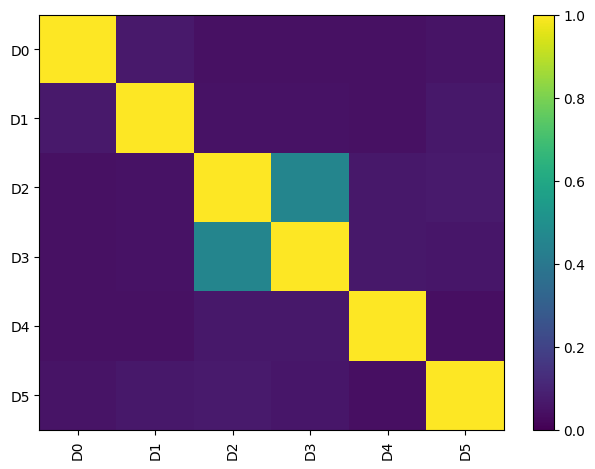

In [104]:
plot_heatmap(
    dsm, 
    row_labels=[f"D{i}" for i in range(dsm.shape[0])],
    col_labels=[f"D{j}" for j in range(dsm.shape[1])],
    vmin=0, 
    vmax=1,
    save_path= "../../Graphs/disease_similarity_heatmap.png"
)
